exists: True


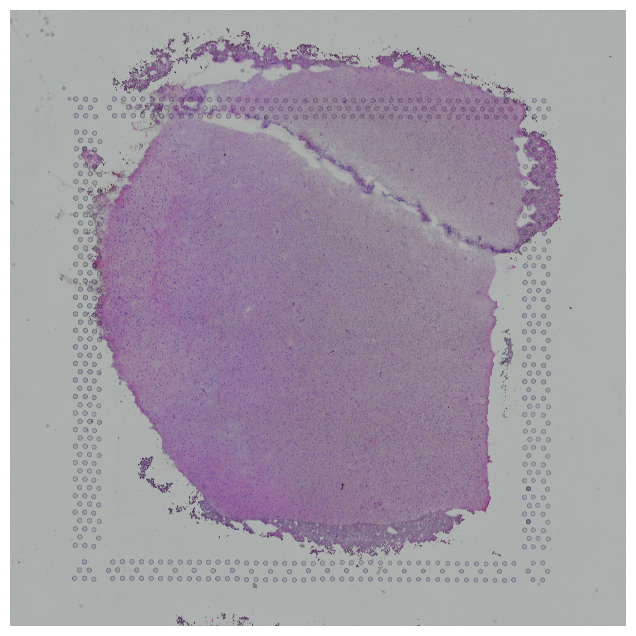

shape: (13332, 13332, 3) dtype: uint8


In [1]:
import os
import cv2
import matplotlib.pyplot as plt

# 注意：你当前 notebook 在 HGM 目录下，Data 在上一级目录
img_path = r"../Data/1.DLPFC/151507/spatial/full_image.tif"
print("exists:", os.path.exists(img_path))

img = cv2.imread(img_path)
if img is None:
    print("读取失败，请检查路径或文件名")
else:
    # OpenCV 读出来是 BGR，显示前转成 RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    print("shape:", img.shape, "dtype:", img.dtype)

e:\Miniconda3\envs\hgm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\16562\AppData\Local\Temp\ipykernel_7356\4055231084.py:2: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(r"../Data/1.DLPFC/151507/")
e:\Miniconda3\envs\hgm\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
e:\Miniconda3\envs\hgm\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


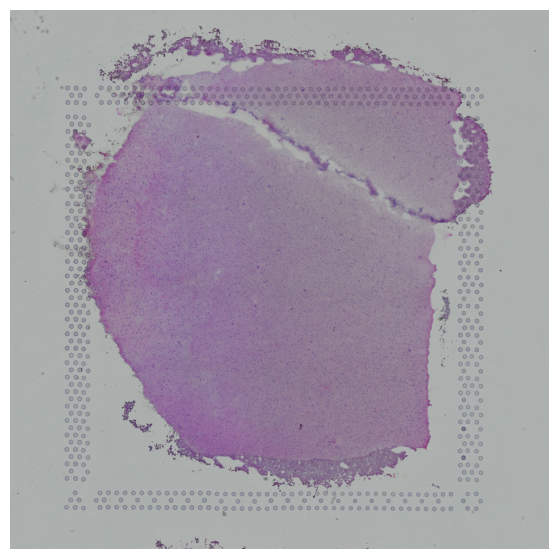

In [2]:
import scanpy as sc
adata = sc.read_visium(r"../Data/1.DLPFC/151507/")
adata.var_names_make_unique()
hires=adata.uns["spatial"]['151507']['images']['hires']
plt.figure(figsize=(7,7))
plt.imshow(hires)
plt.axis("off")
plt.show()

In [3]:
from torchvision import models, transforms
from torch import nn
import torch

model_name = 'vit'  # 可选: resnet18/resnet50/vgg16/densenet121/vit

if model_name == "resnet18":
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Identity()
elif model_name == "resnet50":
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.fc = nn.Identity()
elif model_name == "vgg16":
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
    model.classifier = nn.Sequential(*list(model.classifier.children())[:-1])
elif model_name == "densenet121":
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    model.classifier = nn.Identity()
elif model_name == "vit":
    model = models.vit_b_32(weights=models.ViT_B_32_Weights.DEFAULT)
    model.heads = nn.Identity()
else:
    raise ValueError(f"Unsupported model_name: {model_name}")

In [4]:
beta_half=112
subimages = []

position = adata.obsm['spatial']
max_x=img.shape[0]
max_y=img.shape[1]
for i in range(len(position)):
    nbs=img[max(0,int(position[i][0])-beta_half):min(max_x,int(position[i][0])+beta_half+1),max(0,int(position[i][1])-beta_half):min(max_y,int(position[i][1])+beta_half+1)]
    subimages.append(nbs)

encoder = model.cuda().eval()
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
input_tensors = torch.stack([transform(subimg) for subimg in subimages], dim=0).to("cuda")
with torch.no_grad():
    features = encoder(input_tensors).cpu().numpy()

In [5]:
from dhg import Hypergraph
from sklearn.neighbors import NearestNeighbors

nn=NearestNeighbors(n_neighbors=8+1, metric='cosine').fit(features)
indices=nn.kneighbors(features,return_distance=False)
ihg=Hypergraph(num_v=features.shape[0], e_list=indices.tolist())
print(f'img hypergraph: num_v={ihg.num_v}, num_e={ihg.num_e}')

img hypergraph: num_v=4226, num_e=4212
